**Частина 1**

В якості домашнього завдання вам пропонується створити нейронну мережу за допомогою механізмів Keras, яка буде класифікувати товари із датасету fasion_mnist.

На відміну від попереднього завдання вам пропонується створити згорткову нейромережу. Підберіть архітектуру мережі та навчіть її на даних із датасету fasion_mnist. Спробуйте досягти максимально можливої точності класифікації за рахунок маніпуляції параметрами мережі. Порівняйте точність отриманої згорткової мережі з точністю багатошарової мережі з попереднього завдання. Зробіть висновки.

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
from keras import models
from keras import layers
from sklearn.preprocessing import StandardScaler
from keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
checkpoint_path_cnn = '/content/drive/MyDrive/best_model_cnn.keras'
checkpoint_path_vgg16 = '/content/drive/MyDrive/best_model_vgg16.keras'

In [5]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [8]:
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train_one_hot = to_categorical(y_train,num_classes=10)

y_test_one_hot = to_categorical(y_test,num_classes=10)

In [9]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

time_start = time.time()

model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28, 28, 1),padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
model.compile(loss='categorical_crossentropy', optimizer='nadam', metrics=['accuracy'])

In [11]:
# Add the checkpoint for best model
early_stopping = EarlyStopping(monitor='val_accuracy',patience=5,restore_best_weights=True)
checkpoint_cnn = ModelCheckpoint(checkpoint_path_cnn,monitor='val_accuracy',mode='max',save_best_only=True,verbose=1)

In [12]:

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)
history = model.fit(datagen.flow(X_train, y_train_one_hot, batch_size=128),
    epochs=30,
    validation_data=(X_test, y_test_one_hot),  # or a held-out val split
    callbacks=[early_stopping, checkpoint_cnn, reduce_lr])

test_loss,test_accuracy = model.evaluate(X_test,y_test_one_hot)

print('Test accuracy: ', test_accuracy)

Epoch 1/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7065 - loss: 0.8076
Epoch 1: val_accuracy improved from None to 0.73110, saving model to /content/drive/MyDrive/best_model_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model_cnn.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.7718 - loss: 0.6180 - val_accuracy: 0.7311 - val_loss: 0.6385 - learning_rate: 0.0010
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8338 - loss: 0.4463
Epoch 2: val_accuracy improved from 0.73110 to 0.85110, saving model to /content/drive/MyDrive/best_model_cnn.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model_cnn.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.8406 - loss: 0.4327 - val_accuracy: 0.8511 - val_loss: 0.3826 - learning_rate: 0.0010
Epoch 3/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8537 - loss: 0.3985
Epoch 3: val_accuracy did not improve from 0.85110
469/469 ━━━━━━━

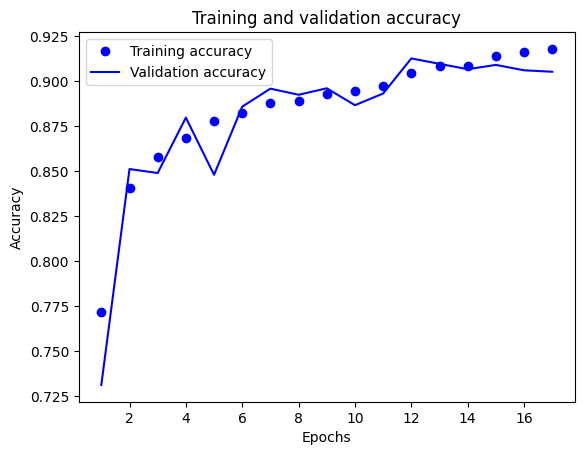

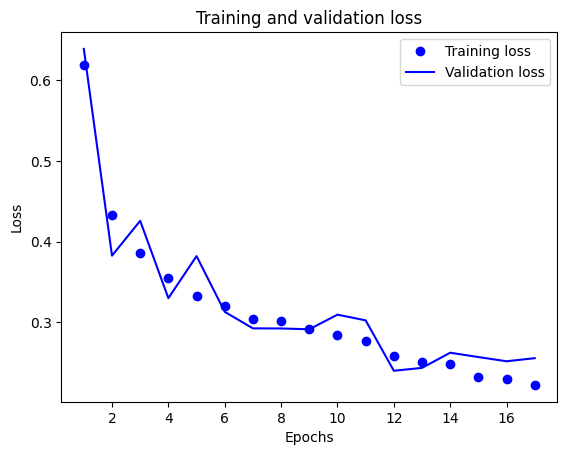

In [13]:
accuracy_values = history.history['accuracy']
val_accuracy_values = history.history['val_accuracy']

loss_values = history.history['loss']
val_loss_values = history.history['val_loss']

epochs = range(1,len(accuracy_values) + 1)

plt.plot(epochs, accuracy_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_values, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Висновок**

Згорткова мережа показала точність 91.83% проти 90.11% у попередньої повнозв'язної мережі — приріст невеликий, але очікуваний. Різниця пояснюється тим, що CNN бачить зображення як зображення, а не як плаский набір пікселів, тому вловлює форми та контури речей краще.


**Частина 2**

В цій частині ми знову будемо працювати з датасетом fasion_mnist.

На відміну від попереднього завдання вам пропонується створити згорткову нейромережу, що використовує VGG16 в якості згорткової основи.

Навчіть отриману мережу на даних із датасету fasion_mnist. Спробуйте досягти максимально можливої точності класифікації за рахунок маніпуляції параметрами мережі. Під час навчання використовуйте прийоми донавчання та виділення ознак.
Порівняйте точність отриманої згорткової мережі з точністю багатошарової мережі з попереднього завдання. Зробіть висновки.


In [14]:
from tensorflow.keras.applications.vgg16 import VGG16

In [15]:
X_train_rgb = tf.image.resize(tf.image.grayscale_to_rgb(tf.constant(X_train)), (48, 48))
X_test_rgb = tf.image.resize(tf.image.grayscale_to_rgb(tf.constant(X_test)), (48, 48))

In [16]:
conv_base = VGG16(weights="imagenet", include_top=False,input_shape=(48, 48, 3))

model_vgg16 = models.Sequential([
    conv_base,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
model_vgg16.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 14,781,642 (56.39 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
conv_base.trainable = True
for layer in conv_base.layers:
    if layer.name not in ['block4_conv1','block4_conv2','block4_conv3','block5_conv1', 'block5_conv2', 'block5_conv3']:
        layer.trainable = False
    else:
        layer.trainable = True
model_vgg16.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Nadam(learning_rate=5e-6), metrics=['accuracy'])

In [19]:
train_features = conv_base.predict(X_train_rgb, batch_size=128, verbose=1)
test_features = conv_base.predict(X_test_rgb, batch_size=128, verbose=1)

469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 63ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step


In [20]:
early_stopping_vgg16 = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoint_vgg16 = ModelCheckpoint(checkpoint_path_vgg16, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
reduce_lr_vgg16 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

In [21]:
datagen.fit(X_train_rgb)
history_vgg16 = model_vgg16.fit(datagen.flow(X_train_rgb, y_train_one_hot, batch_size=128),
    epochs=30,
    validation_data=(X_test_rgb, y_test_one_hot),
    callbacks=[early_stopping_vgg16, checkpoint_vgg16, reduce_lr_vgg16])

test_loss,test_accuracy = model_vgg16.evaluate(X_test_rgb,y_test_one_hot)

print('Test accuracy: ', test_accuracy)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.5246 - loss: 1.3790
Epoch 1: val_accuracy improved from None to 0.86190, saving model to /content/drive/MyDrive/best_model_vgg16.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model_vgg16.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 206ms/step - accuracy: 0.7050 - loss: 0.8617 - val_accuracy: 0.8619 - val_loss: 0.3886 - learning_rate: 5.0000e-06
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8387 - loss: 0.4619
Epoch 2: val_accuracy improved from 0.86190 to 0.88260, saving model to /content/drive/MyDrive/best_model_vgg16.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model_vgg16.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 172ms/step - accuracy: 0.8460 - loss: 0.4403 - val_accuracy: 0.8826 - val_loss: 0.3285 - learning_rate: 5.0000e-06
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.8614 - loss: 0.3919
Epoch 3: val_accuracy improved from 0.88260 

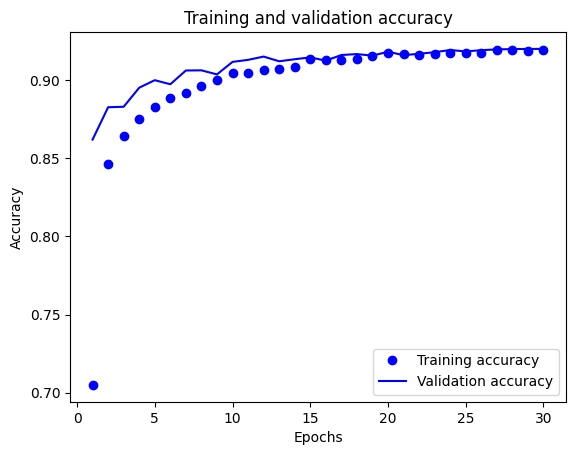

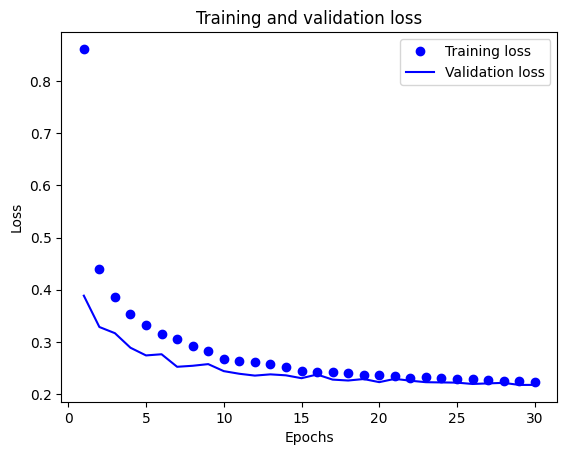

In [22]:
accuracy_values_vgg16 = history_vgg16.history['accuracy']
val_accuracy_values_vgg16 = history_vgg16.history['val_accuracy']

loss_values_vgg16 = history_vgg16.history['loss']
val_loss_values_vgg16 = history_vgg16.history['val_loss']

epochs_vgg16 = range(1,len(accuracy_values_vgg16) + 1)

plt.plot(epochs_vgg16, accuracy_values_vgg16, 'bo', label='Training accuracy')
plt.plot(epochs_vgg16, val_accuracy_values_vgg16, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs_vgg16, loss_values_vgg16, 'bo', label='Training loss')
plt.plot(epochs_vgg16, val_loss_values_vgg16, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
import json
with open("/content/drive/MyDrive/history_cnn.json", "w") as f:
    json.dump(history.history, f)
with open("/content/drive/MyDrive/history_vgg16.json", "w") as f:
    json.dump(history_vgg16.history, f)

**Висновок**

VGG16 із донавчанням дала 92.41% — трохи краще за власну CNN (91.83%), але не значний стрибок. Спочатку, з повністю замороженою базою , точність трималась на рівні близько 85%, а після розморожування block4 і block5 з дуже малим learning rate вона піднялась до 92.41% — тобто саме донавчання дало приріст майже у 7 відсоткових пунктів.

